<a href="https://colab.research.google.com/github/Bunty-Bot/deep_learning_MBFProject/blob/main/DL_MBFProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Importing all the required libraries
import os
import re
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from sklearn.metrics import accuracy_score
from torch.utils.data import Dataset
from torch.utils.data import RandomSampler
from tqdm import tqdm
from sklearn.metrics import accuracy_score, classification_report
import copy

In [2]:
# Cloning the git repository with the Data
!git clone https://git.wur.nl/bioinformatics/grs34806-deep-learning-project-data.git
os.chdir("grs34806-deep-learning-project-data")

Cloning into 'grs34806-deep-learning-project-data'...
remote: Enumerating objects: 21, done.
remote: Total 21 (delta 0), reused 0 (delta 0), pack-reused 21 (from 1)
Receiving objects: 100% (21/21), 8.74 MiB | 6.11 MiB/s, done.


#Data Loading

In [ ]:
# Analysing the data structure for further analysis
seqfile = "len100_200_n1000.seq"
posfile = "len100_200_n1000.pos"

print("First 5 entries from seqfile:")
with open(seqfile, 'r') as f:
  for k, line in enumerate(f):
    if k < 5:
      print(line.strip())
    else:
      break

print("\nFirst 5 entries from posfile:")
with open(posfile, 'r') as f:
  for k, line in enumerate(f):
    if k < 5:
      print(line.strip())
    else:
      break

First 5 entries from seqfile:
seq1	MQICGLVKTAKTPSCWSTVPYGREVGSPMTHQQHETERLQYKRWSGCNGFHGGKIRQYLFNMQGTDCKTDQTAGMAISESFLDFQGDHSYEELNAHPIFQTWPPNNSIRDDCL
seq2	MTGVKGTYGTPNVFQSTNEVSSGDQKIPWPKTEQTACLWGLPLSQFPIRKVIREIDNANTAIINLSLQDPNGNCNCMSKDSYTWWFRYARFHRCGRCIWMPWNGDRCDKYEKYYTDNMLYPEPNQLDSDRIKRGACHSDGMTDHGRDNGKWCCFVINLDDPSHTLP
seq3	MCHYAWCMWNTGCHWGINEEWAFHDKDLQGFPRKLHRPTRPKHYDTCLDDFSMCSTMCEARNVQRYNNWDRVRNRSQNVFDSYQDISRRAHFDSRQDDVLTDTKCYTNEFCHCELSPDMLFLGRTPNTSQAKPHIHVITRPNCNCHPRNQWATMIYYQWKLRQESETVIDQNKGCFSIFAKKEAGTWGIEFTLLYAK
seq4	MQVLNSMLDKVTQDWGKKCGLVKTAKTPQFWILVRRNPSVPVAAAMSINCFSTPRHELYKVRMMGWGSLYKNRQTYNSLSTLMRHSSMPSGVTDCVYWAVFGESIDDDWAWWLRADNDFLWFGNDTDRSIGLYINSCSRVDWMWANHFSE
seq5	MKNHQGCCPSTVGFRNDAQYQISWDVPMAWLWLDRPVKLYMFHFDTEMRDHFKIQSRVNQPDTYPVETTEPFAMVREPEAWSVTNRWSQNSRTWRNMCNTLIINNFEKYDANYVWRWQYWWERQGKRLPHWLPC

First 5 entries from posfile:
seq1
seq4
seq7
seq9
seq10


In [ ]:
def read(seqfile, posfile):
    """
    Read a dataset from provided sequence and positive file.

    Args:
        seqfile : sequence file with one sequence per line
        posfile : list of positive IDs (one per line)

    Returns:
        sequences : list[str]   amino acid sequences
        labels    : list[int]   1 = functional,  0 = not functional
    """
    seq_dict = {}

    with open(seqfile) as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            # Using regex function extracting the sequence
            match = re.match(r"(seq\d+)\t([A-Z]+)", line)
            if not match:
                continue

            pid, seq = match.groups()

            if pid in seq_dict:
                raise ValueError(f"Duplicate ID found: {pid}")

            seq_dict[pid] = seq

    pos_ids = set()
    with open(posfile) as f:
        for line in f:
            pid = line.strip()
            if pid:
                pos_ids.add(pid)

    sequences = []
    labels = []

    for pid, seq in seq_dict.items():
        sequences.append(seq)
        labels.append(1 if pid in pos_ids else 0)

    return sequences, labels

In [ ]:
def plot_label_distribution(labels,title="Positive and Negative samples in the Data"):
    """
    Plot the distribution of positive and negative labels.

    Args:
        labels (list[int]): Binary labels where 1 = positive and 0 = negative.
        title (str): Plot title.

    Returns:
        None. Displays the bar chart.
    """
    if len(labels) == 0:
        raise ValueError("labels is empty; cannot plot class distribution.")

    counts = [sum(labels), len(labels) - sum(labels)]
    total = len(labels)

    fig, ax = plt.subplots(figsize=(5, 4))
    bars = ax.bar(
        ["Positive (functional)", "Negative (not functional)"],
        counts,
        color=["#2a9d8f", "#e76f51"],
        edgecolor="white",
        linewidth=0.8,
    )

    for bar, count in zip(bars, counts):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 5,
            f"{count} ({100 * count / total:.1f}%)",
            ha="center",
            va="bottom",
            fontsize=11,
        )

    ax.set_ylabel("Number of sequences")
    ax.set_title(title, fontweight="bold")
    ax.set_ylim(0, max(counts) * 1.15)

    plt.tight_layout()
    plt.show()

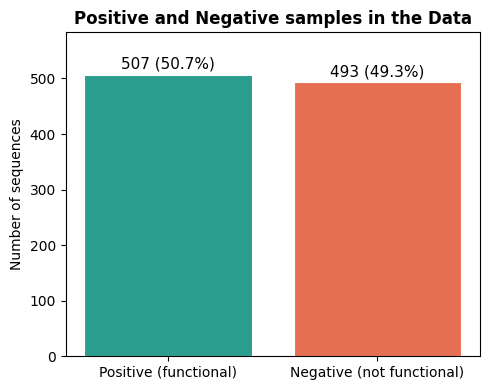

In [ ]:
seq, label = read(seqfile, posfile)
plot_label_distribution(label)


#Data Preprocessing

In [ ]:
def generate_train_val_test(datalist, labellist, random_state=42):
    """
    Split data into train, validation, and test sets using a 70/15/15 split.

    Args:
        datalist: List of sequences.
        labellist (list): List of binary labels.
        random_state (int): Seed for reproducibility.

    Returns:
        train_seq, train_lab, val_seq, val_lab, test_seq, test_lab
    """
    if len(datalist) != len(labellist):
        raise ValueError("datalist and labellist must have the same length")
    if len(datalist) == 0:
        raise ValueError("Input data is empty")

    # Step 1: split train (70%) vs temp (30%)
    seq_train, seq_temp, lab_train, lab_temp = train_test_split(
        datalist, labellist,
        test_size=0.30,
        random_state=random_state,
        stratify=labellist
    )

    # Step 2: split temp 50/50 → 15% val, 15% test
    seq_val, seq_test, lab_val, lab_test = train_test_split(
        seq_temp, lab_temp,
        test_size=0.50,
        random_state=random_state,
        stratify=lab_temp
    )

    # Print exact counts
    print(f"Train: {len(seq_train)} sequences, {sum(lab_train)} positive")
    print(f"Val  : {len(seq_val)} sequences, {sum(lab_val)} positive")
    print(f"Test : {len(seq_test)} sequences, {sum(lab_test)} positive")
    print(f"Total: {len(datalist)} sequences")

    return seq_train, lab_train, seq_val, lab_val, seq_test, lab_test

In [ ]:
print(generate_train_val_test(seq, label))

Train: 700 sequences, 355 positive
Val  : 150 sequences, 76 positive
Test : 150 sequences, 76 positive
Total: 1000 sequences
(['...'], [1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 

In [ ]:
def tokenize(datalist, map2num, non_aa_num=20):
    """Convert sequences to numbers for neural net."""
    seqs = []
    for sequence in datalist:
        seqs.append([map2num.get(aa, non_aa_num) for aa in sequence])
    return seqs

In [ ]:
def tokenize_onehot(datalist, max_length=200):
    aa_list = "ACDEFGHIKLMNPQRSTVWY"
    aa_map = {aa: i for i, aa in enumerate(aa_list)}
    encoded = []
    for sequence in datalist:
        row = [[0] * 20 for _ in range(max_length)]
        for i, aa in enumerate(sequence[:max_length]):
            if aa in aa_map:
                row[i][aa_map[aa]] = 1
        encoded.append(row)
    return encoded

In [ ]:
def truncate_pad(line, num_steps, padding_token=20):
    """Truncate or pad a sequence to exactly num_steps."""
    if len(line) > num_steps:
        return line[:num_steps]
    return line + [padding_token] * (num_steps - len(line))

In [ ]:
def build_seq_array(lines, num_steps):
    """Stack all sequences into one integer tensor [N, num_steps]."""
    array = torch.tensor([truncate_pad(l, num_steps) for l in lines])
    return array

In [ ]:
def load_data(batch_size, num_steps, dataset):
  mapaa2num = {aa: i for (i, aa)
  in enumerate(list("ACDEFGHIKLMNPQRSTVWY"))}
  seq,lab = dataset
  seq = tokenize(seq, mapaa2num)
  seq_array = build_seq_array(seq, num_steps)
  dataset = TensorDataset(seq_array, lab)
  data_iter = DataLoader(dataset, batch_size=batch_size, shuffle=True)
  return data_iter

#Train model using embedding method

In [ ]:
class CNN1D(nn.Module):
    def __init__(self, vocab_size, context_size, conv_channels=128,
                 use_bias=False, dropout=0.0):   # <-- add dropout param
        super().__init__()
        self.embedding = nn.Embedding(vocab_size + 1, 64, padding_idx=vocab_size)

        self.cnn = nn.Sequential(
            nn.Conv1d(64, conv_channels, kernel_size=3, padding='same', bias=use_bias),
            nn.ReLU(),
            nn.Dropout(dropout),          # <-- add dropout
            nn.MaxPool1d(2, 2),
            nn.Conv1d(conv_channels, conv_channels, kernel_size=3, padding='same', bias=use_bias),
            nn.ReLU(),
            nn.Dropout(dropout),          # <-- add dropout
            nn.MaxPool1d(2, 2),
            nn.Flatten(1, -1),
            nn.Linear(int(conv_channels * context_size / 4), 1, bias=use_bias)
        )

    def forward(self, X, targets=None):
        x = self.embedding(X).transpose(1, 2)
        logits = self.cnn(x).squeeze(1)
        loss = None
        if targets is not None:
            loss = F.binary_cross_entropy_with_logits(logits, targets.float())
        return logits, loss

In [ ]:
class SequenceDataset(TensorDataset):
    vocab_size    = 20
    padding_token = 20  # unknown/padding index

    def __init__(self, sequences, labels, context_size=200):
        mapaa2num = {aa: i for i, aa in enumerate(list("ACDEFGHIKLMNPQRSTVWY"))}
        tokenized = tokenize(sequences, mapaa2num, non_aa_num=self.padding_token)  # your existing function!
        self.X = torch.tensor([self._pad(t, context_size) for t in tokenized], dtype=torch.long)
        self.y = torch.tensor(labels, dtype=torch.long)

    def _pad(self, tokens, context_size):
        tokens = tokens[:context_size]
        tokens += [self.padding_token] * (context_size - len(tokens))
        return tokens

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

Train: 700 sequences, 355 positive
Val  : 150 sequences, 76 positive
Test : 150 sequences, 76 positive
Total: 1000 sequences


Epoch 1/10: 100%|██████████| 11/11 [00:00<00:00, 14.90it/s]


Epoch 1: train=0.7103, val=0.6995


Epoch 2/10: 100%|██████████| 11/11 [00:00<00:00, 14.64it/s]


Epoch 2: train=0.6926, val=0.6952


...

Epoch 8: train=0.4856, val=0.5523


Epoch 9/10: 100%|██████████| 11/11 [00:00<00:00, 22.47it/s]


Epoch 9: train=0.4249, val=0.5625


Epoch 10/10: 100%|██████████| 11/11 [00:00<00:00, 22.30it/s]


Epoch 10: train=0.4050, val=0.4644


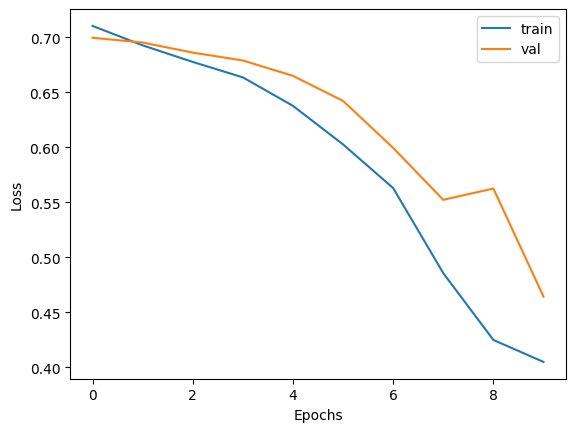

In [ ]:

context_size = 200
batch_size = 64
EPOCHS = 10
patience = 3
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

seq, label = read(seqfile, posfile)
seq_train, lab_train, seq_val, lab_val, seq_test, lab_test = generate_train_val_test(seq, label)

train_dataset = SequenceDataset(seq_train, lab_train, context_size)
val_dataset   = SequenceDataset(seq_val, lab_val, context_size)
test_dataset  = SequenceDataset(seq_test, lab_test, context_size)

train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader   = DataLoader(val_dataset, batch_size=batch_size)
test_dataloader  = DataLoader(test_dataset, batch_size=batch_size)

model = CNN1D(
    vocab_size=SequenceDataset.vocab_size,
    context_size=context_size,
    conv_channels=32,
    dropout=0.35
).to(DEVICE)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-2)

train_losses, val_losses = [], []
best_val_loss = float("inf")
best_state = copy.deepcopy(model.state_dict())
wait = 0

for epoch in range(EPOCHS):
    model.train()
    train_epoch = []

    for x, y in tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{EPOCHS}"):
        x, y = x.to(DEVICE), y.to(DEVICE)

        optimizer.zero_grad()
        _, loss = model(x, y)
        loss.backward()
        optimizer.step()

        train_epoch.append(loss.item())

    model.eval()
    val_epoch = []
    with torch.no_grad():
        for x, y in val_dataloader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            _, val_loss = model(x, y)
            val_epoch.append(val_loss.item())

    avg_train = np.mean(train_epoch)
    avg_val = np.mean(val_epoch)

    train_losses.append(avg_train)
    val_losses.append(avg_val)

    print(f"Epoch {epoch+1}: train={avg_train:.4f}, val={avg_val:.4f}")

    if avg_val < best_val_loss - 1e-3:
        best_val_loss = avg_val
        best_state = copy.deepcopy(model.state_dict())
        wait = 0
    else:
        wait += 1
        if wait >= patience:
            print("Early stopping.")
            break

model.load_state_dict(best_state)

plt.plot(train_losses, label="train")
plt.plot(val_losses, label="val")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [ ]:
def evaluate_accuracy(model, dataset, name, device):
    model.eval()
    all_preds  = []
    all_labels = []

    loader = DataLoader(dataset, batch_size=64)

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            logits, _ = model(x)
            preds = (torch.sigmoid(logits) > 0.5).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y.numpy())

    acc = accuracy_score(all_labels, all_preds)
    print(f"\n--- {name} Accuracy: {acc:.4f} ---")
    print(classification_report(all_labels, all_preds, target_names=['Non-functional', 'Functional']))

# Run on train, val and test
evaluate_accuracy(model, train_dataset, "Train", DEVICE)
evaluate_accuracy(model, val_dataset,   "Validation", DEVICE)
evaluate_accuracy(model, test_dataset,  "Test", DEVICE)


--- Train Accuracy: 0.9343 ---
                precision    recall  f1-score   support

Non-functional       0.98      0.89      0.93       345
    Functional       0.90      0.98      0.94       355

      accuracy                           0.93       700
     macro avg       0.94      0.93      0.93       700
  weighted avg       0.94      0.93      0.93       700


--- Validation Accuracy: 0.8200 ---
                precision    recall  f1-score   support

Non-functional       0.84      0.78      0.81        74
    Functional       0.80      0.86      0.83        76

      accuracy                           0.82       150
     macro avg       0.82      0.82      0.82       150
  weighted avg       0.82      0.82      0.82       150


--- Test Accuracy: 0.8467 ---
                precision    recall  f1-score   support

Non-functional       0.87      0.81      0.84        74
    Functional       0.83      0.88      0.85        76

      accuracy                           0.85       

#Train model using One-Hot Encoding method

In [ ]:
class SequenceDatasetOneHot(TensorDataset):
    vocab_size = 20
    padding_token = 20

    def __init__(self, sequences, labels, context_size=200):
        self.context_size = context_size
        self.X = torch.tensor(self.tokenize_onehot(sequences, context_size), dtype=torch.float32)
        self.y = torch.tensor(labels, dtype=torch.long)

    def tokenize_onehot(self, datalist, max_length=200):
        aa_list = "ACDEFGHIKLMNPQRSTVWY"
        aa_map = {aa: i for i, aa in enumerate(aa_list)}
        encoded = []

        for sequence in datalist:
            row = [[0] * 20 for _ in range(max_length)]
            for i, aa in enumerate(sequence[:max_length]):
                if aa in aa_map:
                    row[i][aa_map[aa]] = 1
            encoded.append(row)

        return encoded

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [ ]:
class CNN1D(nn.Module):
    def __init__(self, context_size, conv_channels=128, use_bias=False, dropout=0.0):
        super().__init__()

        self.cnn = nn.Sequential(
            nn.Conv1d(20, conv_channels, kernel_size=3, padding='same', bias=use_bias),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.MaxPool1d(2, 2),

            nn.Conv1d(conv_channels, conv_channels, kernel_size=3, padding='same', bias=use_bias),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.MaxPool1d(2, 2),

            nn.Flatten(1, -1),
            nn.Linear(int(conv_channels * context_size / 4), 1, bias=use_bias)
        )

    def forward(self, X, targets=None):
        x = X.transpose(1, 2)   # (batch, 20, context_size)
        logits = self.cnn(x).squeeze(1)

        loss = None
        if targets is not None:
            loss = F.binary_cross_entropy_with_logits(logits, targets.float())

        return logits, loss

Train: 700 sequences, 355 positive
Val  : 150 sequences, 76 positive
Test : 150 sequences, 76 positive
Total: 1000 sequences


Epoch 1/10: 100%|██████████| 11/11 [00:02<00:00,  3.70it/s]


Epoch 1: train=0.6991, val=0.6959


Epoch 2/10: 100%|██████████| 11/11 [00:01<00:00,  7.25it/s]


Epoch 2: train=0.6863, val=0.6922


...

Epoch 8: train=0.4855, val=0.6149


Epoch 9/10: 100%|██████████| 11/11 [00:01<00:00,  7.04it/s]


Epoch 9: train=0.4378, val=0.5951


Epoch 10/10: 100%|██████████| 11/11 [00:01<00:00,  6.93it/s]


Epoch 10: train=0.3973, val=0.5080


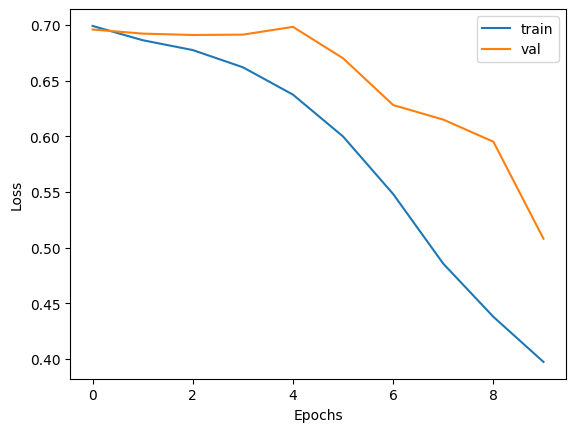

In [ ]:
context_size = 200
batch_size = 64
EPOCHS = 10
patience = 3
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

seq, label = read(seqfile, posfile)
seq_train, lab_train, seq_val, lab_val, seq_test, lab_test = generate_train_val_test(seq, label)

train_dataset = SequenceDatasetOneHot(seq_train, lab_train, context_size)
val_dataset   = SequenceDatasetOneHot(seq_val, lab_val, context_size)
test_dataset  = SequenceDatasetOneHot(seq_test, lab_test, context_size)

model = CNN1D(context_size=context_size, dropout=0.5).to(DEVICE)

train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader   = DataLoader(val_dataset, batch_size=batch_size)
test_dataloader  = DataLoader(test_dataset, batch_size=batch_size)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-2)

train_losses, val_losses = [], []
best_val_loss = float("inf")
best_state = copy.deepcopy(model.state_dict())
wait = 0

for epoch in range(EPOCHS):
    model.train()
    train_epoch = []

    for x, y in tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{EPOCHS}"):
        x, y = x.to(DEVICE), y.to(DEVICE)

        optimizer.zero_grad()
        _, loss = model(x, y)
        loss.backward()
        optimizer.step()

        train_epoch.append(loss.item())

    model.eval()
    val_epoch = []
    with torch.no_grad():
        for x, y in val_dataloader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            _, val_loss = model(x, y)
            val_epoch.append(val_loss.item())

    avg_train = np.mean(train_epoch)
    avg_val = np.mean(val_epoch)

    train_losses.append(avg_train)
    val_losses.append(avg_val)

    print(f"Epoch {epoch+1}: train={avg_train:.4f}, val={avg_val:.4f}")

    if avg_val < best_val_loss - 1e-3:
        best_val_loss = avg_val
        best_state = copy.deepcopy(model.state_dict())
        wait = 0
    else:
        wait += 1
        if wait >= patience:
            print("Early stopping.")
            break

model.load_state_dict(best_state)

plt.plot(train_losses, label="train")
plt.plot(val_losses, label="val")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [ ]:
def evaluate_accuracy(model, dataset, name, device):
    model.eval()
    all_preds  = []
    all_labels = []

    loader = DataLoader(dataset, batch_size=64)

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            logits, _ = model(x)
            preds = (torch.sigmoid(logits) > 0.5).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y.numpy())

    acc = accuracy_score(all_labels, all_preds)
    print(f"\n--- {name} Accuracy: {acc:.4f} ---")
    print(classification_report(all_labels, all_preds, target_names=['Non-functional', 'Functional']))

# Run on train, val and test
evaluate_accuracy(model, train_dataset, "Train", DEVICE)
evaluate_accuracy(model, val_dataset,   "Validation", DEVICE)
evaluate_accuracy(model, test_dataset,  "Test", DEVICE)


--- Train Accuracy: 0.9300 ---
                precision    recall  f1-score   support

Non-functional       0.95      0.91      0.93       345
    Functional       0.91      0.95      0.93       355

      accuracy                           0.93       700
     macro avg       0.93      0.93      0.93       700
  weighted avg       0.93      0.93      0.93       700


--- Validation Accuracy: 0.7800 ---
                precision    recall  f1-score   support

Non-functional       0.77      0.80      0.78        74
    Functional       0.79      0.76      0.78        76

      accuracy                           0.78       150
     macro avg       0.78      0.78      0.78       150
  weighted avg       0.78      0.78      0.78       150


--- Test Accuracy: 0.8067 ---
                precision    recall  f1-score   support

Non-functional       0.84      0.76      0.79        74
    Functional       0.78      0.86      0.82        76

      accuracy                           0.81       